# Geospatial Feature Extraction

## Objectives
1. Extract elevation from Digital Elevation Model (DEM)
2. Extract slope values from slope raster
3. Extract land cover classification
4. Calculate derived terrain metrics
5. Merge with engineered features

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.geospatial_processing import GeospatialProcessor, create_mock_geospatial_features
from src.utils import load_config

sns.set_style('whitegrid')
print("Libraries imported successfully!")

try:
    import rasterio
    print("✓ Rasterio available for geospatial processing")
    RASTERIO_AVAILABLE = True
except ImportError:
    print("⚠ Rasterio not available - will use mock features")
    RASTERIO_AVAILABLE = False

Libraries imported successfully!
✓ Rasterio available for geospatial processing


## Load Data and Configuration

In [2]:
config = load_config('../configs/train_config.yaml')

# Try to load engineered features from previous notebook
try:
    df = pd.read_parquet('../data/processed/engineered_features.parquet')
    print(f"Loaded engineered features: {df.shape}")
except FileNotFoundError:
    # Load raw data
    try:
        df = pd.read_parquet('../data/raw/training_data.parquet')
    except FileNotFoundError:
        # Create synthetic data
        np.random.seed(42)
        n_samples = 1000
        df = pd.DataFrame({
            'SamplePointID': range(1, n_samples + 1),
            'Date': pd.date_range('2022-01-01', periods=n_samples, freq='D'),
            'Latitude': np.random.uniform(-45, -35, n_samples),
            'Longitude': np.random.uniform(165, 175, n_samples),
        })
    print(f"Loaded raw data: {df.shape}")

# Ensure we have lat/lon
if 'Latitude' not in df.columns or 'Longitude' not in df.columns:
    raise ValueError("DataFrame must contain Latitude and Longitude columns")

df.head()

Loaded engineered features: (1207087, 50)


,Latitude_x,Longitude_x,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,Latitude_y,Longitude_y,nir,green,...,pet_x_dayofyear,NDVI_x_pet,NDWI_x_pet,NDMI_x_pet,NBR_x_pet,NDVI_x_lat_sin,NDVI_x_lat_cos,NDVI_x_lon_sin,NDVI_x_lon_cos,NDVI_weighted_distance
0,-25.127778,27.628889,2011-01-02,128.967,377.0,163.0,-25.127778,27.628889,7814.0,5189.5,...,338.60000,34.169866,-34.169866,13.447645,33.662596,-0.085705,0.182730,0.093597,0.178816,0.661284
1,-25.127778,27.628889,2011-01-02,128.967,377.0,163.0,-25.127778,27.628889,7814.0,5189.5,...,308.80002,31.162597,-31.162597,12.264126,30.699971,-0.092768,0.179247,0.106306,0.171565,0.991678
2,-25.127778,27.628889,2011-01-02,128.967,377.0,163.0,-25.127778,27.628889,7814.0,5189.5,...,380.20000,38.367936,-38.367936,15.099807,37.798343,-0.098343,0.176250,0.090287,0.180509,0.184255
3,-25.127778,27.628889,2011-01-02,128.967,377.0,163.0,-25.127778,27.628889,7814.0,5189.5,...,316.40000,31.929550,-31.929550,12.565962,31.455539,-0.113823,0.166673,0.065677,0.190845,2.013737
4,-25.127778,27.628889,2011-01-02,128.967,377.0,163.0,-24.695140,27.409060,15543.0,10647.0,...,338.60000,31.649210,-31.649210,22.338045,39.663880,-0.079383,0.169250,0.086693,0.165625,0.612502


## Initialize Geospatial Processor

In [3]:
# Get geospatial file paths from config
dem_path = config['geospatial_files'].get('dem_elevation')
slope_path = config['geospatial_files'].get('slope_map')
landcover_path = config['geospatial_files'].get('worldcover')

print("Geospatial raster paths:")
print(f"  DEM: {dem_path}")
print(f"  Slope: {slope_path}")
print(f"  Land Cover: {landcover_path}")

# Check if files exist
dem_exists = Path(dem_path).exists() if dem_path else False
slope_exists = Path(slope_path).exists() if slope_path else False
landcover_exists = Path(landcover_path).exists() if landcover_path else False

print(f"\nFile availability:")
print(f"  DEM: {'✓' if dem_exists else '✗'}")
print(f"  Slope: {'✓' if slope_exists else '✗'}")
print(f"  Land Cover: {'✓' if landcover_exists else '✗'}")

if not (dem_exists and slope_exists and landcover_exists):
    print("\n⚠ Raster files not found - will create mock geospatial features")
    USE_MOCK = True
else:
    USE_MOCK = False
    geo_processor = GeospatialProcessor(
        dem_path=dem_path,
        slope_path=slope_path,
        landcover_path=landcover_path
    )

Geospatial raster paths:
  DEM: data/external/dem_elevation.tif
  Slope: data/external/slope_map.tif
  Land Cover: data/external/worldcover_esa.tif

File availability:
  DEM: ✗
  Slope: ✗
  Land Cover: ✗

⚠ Raster files not found - will create mock geospatial features


## 1. Extract Elevation Features

In [4]:
if USE_MOCK or not RASTERIO_AVAILABLE:
    # Create mock elevation
    df['elevation'] = 100 + (df['Latitude'] - df['Latitude'].min()) * 10 + np.random.normal(0, 20, len(df))
    print("✓ Mock elevation features created")
else:
    # Extract real elevation
    df = geo_processor.extract_elevation(df)
    print("✓ Elevation extracted from DEM")

# Display statistics
print(f"\nElevation statistics:")
print(f"  Min: {df['elevation'].min():.2f} m")
print(f"  Max: {df['elevation'].max():.2f} m")
print(f"  Mean: {df['elevation'].mean():.2f} m")
print(f"  Std: {df['elevation'].std():.2f} m")

✓ Mock elevation features created

Elevation statistics:
  Min: 19.59 m
  Max: 293.91 m
  Mean: 160.69 m
  Std: 34.35 m


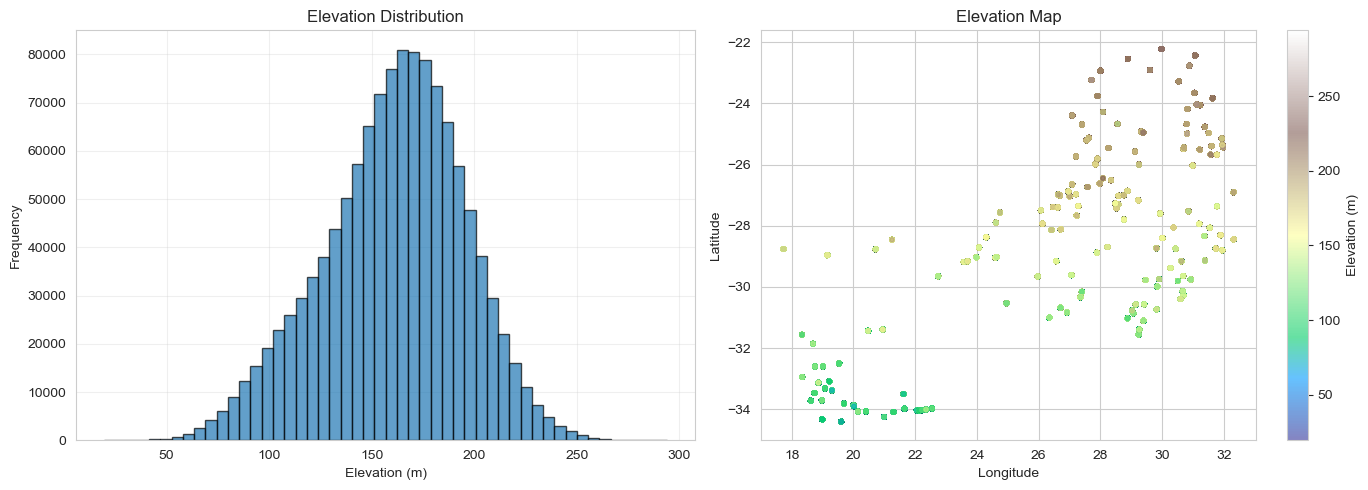

In [5]:
# Visualize elevation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elevation distribution
axes[0].hist(df['elevation'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Elevation Distribution')
axes[0].set_xlabel('Elevation (m)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Spatial distribution
scatter = axes[1].scatter(df['Longitude'], df['Latitude'], 
                         c=df['elevation'], cmap='terrain', s=10, alpha=0.6)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Elevation Map')
plt.colorbar(scatter, ax=axes[1], label='Elevation (m)')

plt.tight_layout()
plt.show()

## 2. Extract Slope Features

In [6]:
if USE_MOCK or not RASTERIO_AVAILABLE:
    # Create mock slope
    df['slope'] = np.abs(np.random.gamma(2, 2, len(df)))
    print("✓ Mock slope features created")
else:
    # Extract real slope
    df = geo_processor.extract_slope(df)
    print("✓ Slope extracted from raster")

# Display statistics
print(f"\nSlope statistics:")
print(f"  Min: {df['slope'].min():.2f}°")
print(f"  Max: {df['slope'].max():.2f}°")
print(f"  Mean: {df['slope'].mean():.2f}°")
print(f"  Std: {df['slope'].std():.2f}°")

✓ Mock slope features created

Slope statistics:
  Min: 0.00°
  Max: 32.76°
  Mean: 4.00°
  Std: 2.83°


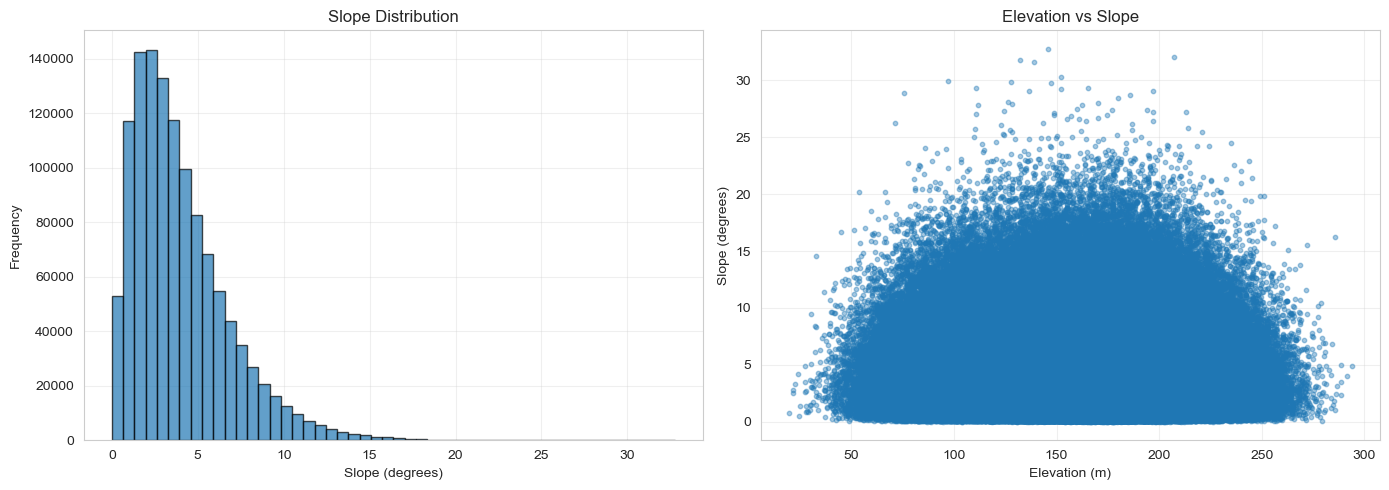

In [7]:
# Visualize slope
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Slope distribution
axes[0].hist(df['slope'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Slope Distribution')
axes[0].set_xlabel('Slope (degrees)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Elevation vs Slope
axes[1].scatter(df['elevation'], df['slope'], alpha=0.4, s=10)
axes[1].set_xlabel('Elevation (m)')
axes[1].set_ylabel('Slope (degrees)')
axes[1].set_title('Elevation vs Slope')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Extract Land Cover Features

In [8]:
if USE_MOCK or not RASTERIO_AVAILABLE:
    # Create mock land cover
    df['landcover'] = np.random.choice([10, 20, 30, 40, 80, 90], len(df))
    # One-hot encode
    for code, name in [(10, 'forest'), (20, 'shrubland'), (30, 'grassland'),
                       (40, 'cropland'), (80, 'water'), (90, 'wetland')]:
        df[f'lc_{name}'] = (df['landcover'] == code).astype(int)
    print("✓ Mock land cover features created")
else:
    # Extract real land cover
    df = geo_processor.extract_landcover(df)
    print("✓ Land cover extracted from ESA WorldCover")

# Display land cover distribution
print(f"\nLand cover distribution:")
print(df['landcover'].value_counts().sort_index())

✓ Mock land cover features created

Land cover distribution:
landcover
10    200617
20    201540
30    200949
40    201007
80    201525
90    201449
Name: count, dtype: int64


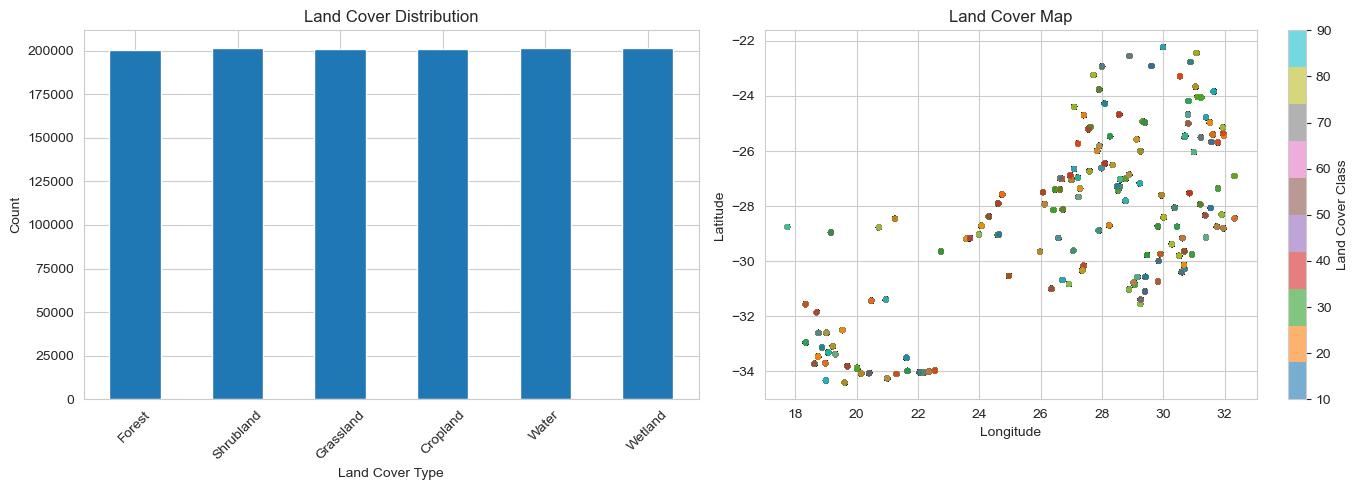

In [9]:
# Visualize land cover
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Land cover distribution
landcover_names = {10: 'Forest', 20: 'Shrubland', 30: 'Grassland', 
                   40: 'Cropland', 80: 'Water', 90: 'Wetland'}
lc_counts = df['landcover'].value_counts().sort_index()
lc_counts.index = lc_counts.index.map(lambda x: landcover_names.get(x, f'Class {x}'))
lc_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Land Cover Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Land Cover Type')
axes[0].tick_params(axis='x', rotation=45)

# Spatial land cover map
scatter = axes[1].scatter(df['Longitude'], df['Latitude'], 
                         c=df['landcover'], cmap='tab10', s=10, alpha=0.6)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Land Cover Map')
plt.colorbar(scatter, ax=axes[1], label='Land Cover Class')

plt.tight_layout()
plt.show()

## 4. Calculate Derived Terrain Metrics

In [10]:
# Terrain ruggedness
df['terrain_ruggedness'] = df['slope'] * (df['elevation'] / (df['elevation'].max() + 1))

# Elevation category
df['elevation_category'] = pd.cut(df['elevation'], bins=5, labels=[0, 1, 2, 3, 4]).astype(int)

# Slope category
df['slope_category'] = pd.cut(
    df['slope'],
    bins=[0, 2, 5, 10, 20, 100],
    labels=[0, 1, 2, 3, 4]
).astype(int)

print("✓ Derived terrain metrics created")
print(f"\nTerrain features:")
print(f"  - terrain_ruggedness")
print(f"  - elevation_category (5 bins)")
print(f"  - slope_category (5 bins)")

✓ Derived terrain metrics created

Terrain features:
  - terrain_ruggedness
  - elevation_category (5 bins)
  - slope_category (5 bins)


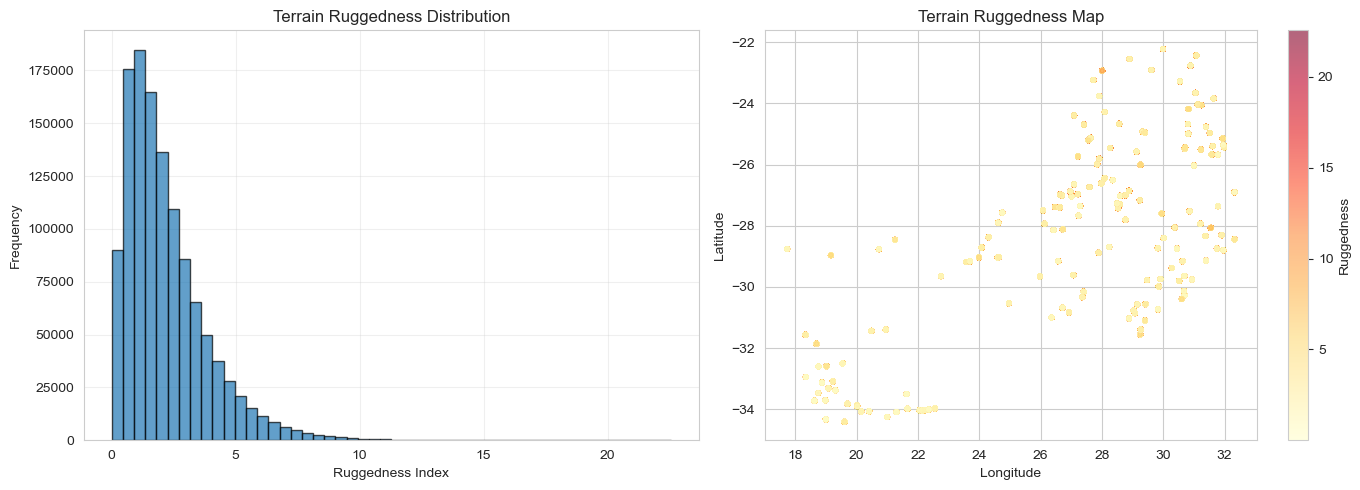

In [11]:
# Visualize terrain complexity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Terrain ruggedness distribution
axes[0].hist(df['terrain_ruggedness'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Terrain Ruggedness Distribution')
axes[0].set_xlabel('Ruggedness Index')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Spatial ruggedness map
scatter = axes[1].scatter(df['Longitude'], df['Latitude'], 
                         c=df['terrain_ruggedness'], cmap='YlOrRd', s=10, alpha=0.6)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Terrain Ruggedness Map')
plt.colorbar(scatter, ax=axes[1], label='Ruggedness')

plt.tight_layout()
plt.show()

## 5. Feature Summary

In [12]:
# Count geospatial features
geo_features = [
    'elevation', 'slope', 'landcover', 'terrain_ruggedness',
    'elevation_category', 'slope_category'
]
geo_features += [col for col in df.columns if col.startswith('lc_')]

print(f"\n{'='*80}")
print(f"GEOSPATIAL FEATURES SUMMARY")
print(f"{'='*80}")
print(f"\nTotal geospatial features: {len(geo_features)}")
print(f"\nFeature groups:")
print(f"  - Elevation: 2 (raw + category)")
print(f"  - Slope: 2 (raw + category)")
print(f"  - Land cover: {len([c for c in df.columns if c.startswith('lc_')])} (one-hot encoded)")
print(f"  - Terrain: 1 (ruggedness index)")
print(f"\nTotal DataFrame shape: {df.shape}")

# Check for missing values
missing = df[geo_features].isna().sum().sum()
print(f"\nMissing values in geospatial features: {missing}")


GEOSPATIAL FEATURES SUMMARY

Total geospatial features: 12

Feature groups:
  - Elevation: 2 (raw + category)
  - Slope: 2 (raw + category)
  - Land cover: 6 (one-hot encoded)
  - Terrain: 1 (ruggedness index)

Total DataFrame shape: (1207087, 62)

Missing values in geospatial features: 0


## 6. Correlation Analysis

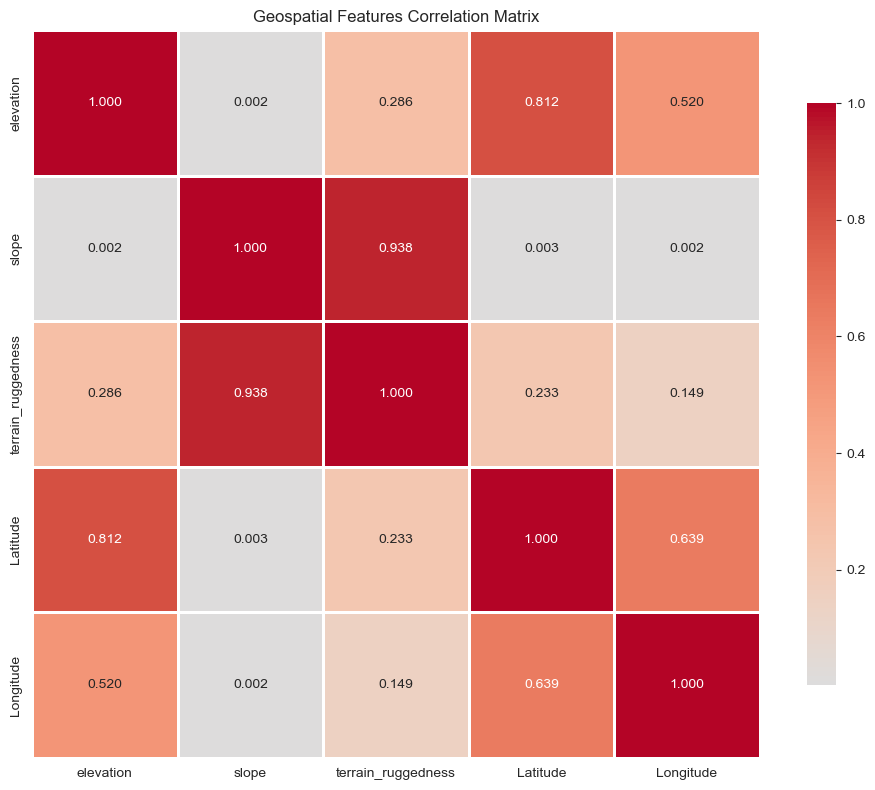

In [13]:
# Correlation matrix of core geospatial features
core_geo = ['elevation', 'slope', 'terrain_ruggedness', 'Latitude', 'Longitude']
core_geo = [c for c in core_geo if c in df.columns]

if len(core_geo) > 2:
    corr = df[core_geo].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Geospatial Features Correlation Matrix')
    plt.tight_layout()
    plt.show()

## 7. Save Enhanced Dataset

In [14]:
# Save enhanced dataset with geospatial features
output_path = Path('../data/processed/features_with_geospatial.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)

df.to_parquet(output_path, index=False)
print(f"\n✅ Dataset with geospatial features saved to: {output_path}")
print(f"   Shape: {df.shape}")
print(f"   Size: {output_path.stat().st_size / 1024:.2f} KB")


✅ Dataset with geospatial features saved to: ..\data\processed\features_with_geospatial.parquet
   Shape: (1207087, 62)
   Size: 72063.25 KB


## Summary

This notebook extracted geospatial features:

### Elevation Features
- ✅ Raw elevation from DEM
- ✅ Elevation categories (5 bins)

### Slope Features  
- ✅ Raw slope values
- ✅ Slope categories (5 bins)

### Land Cover Features
- ✅ Land cover classification
- ✅ One-hot encoded land cover types (6+ classes)

### Derived Metrics
- ✅ Terrain ruggedness index

**Total geospatial features added**: ~15

**Next Steps**:
1. Run `04_full_training_pipeline.ipynb` for production model training
2. Use spatial cross-validation to account for geographic clustering
3. Generate final predictions with `05_submission_generator.ipynb`